## Imports

In [120]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_style('dark')
warnings.filterwarnings('ignore')

## Loads

In [2]:
df = pd.read_excel('Base_de_Vendas_teste.xlsx', parse_dates=['dt_venda'])

## EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15004 entries, 0 to 15003
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   dt_venda                         15004 non-null  datetime64[ns]
 1   nm_localidade_estado             15004 non-null  object        
 2   tp_produtor_canal_aquisicao      15004 non-null  object        
 3   tp_tamanho_produtor              15004 non-null  object        
 4   nm_evento_classificacao_negocio  15004 non-null  object        
 5   vr_venda                         15004 non-null  float64       
 6   Unnamed: 6                       0 non-null      float64       
 7   qt_ingresso                      15004 non-null  float64       
 8   qt_evento                        15004 non-null  float64       
 9   qt_produtor                      15004 non-null  float64       
 10  qt_ingresso_por_evento           15004 non-null  float64  

In [4]:
# Remove unnecessary column
df.drop(columns=['Unnamed: 6'], inplace=True)

In [5]:
# Month sort and sample
df.sort_values(by='dt_venda').reset_index(drop=True, inplace=True)
df.head(10)

,dt_venda,nm_localidade_estado,tp_produtor_canal_aquisicao,tp_tamanho_produtor,nm_evento_classificacao_negocio,vr_venda,qt_ingresso,qt_evento,qt_produtor,qt_ingresso_por_evento,qt_evento_por_produtor,vr_medio_ingresso
0,2033-02-01,ACRE,DIRETO,PEQUENO,CORPORATIVO,218.87,2.0,1.0,1.0,2.0,1.0,152.42
1,2033-02-01,ACRE,DIRETO,PEQUENO,ENTRETENIMENTO,906.49,40.0,4.0,4.0,10.0,1.0,24.34
2,2033-02-01,ACRE,DIRETO,PEQUENO,OUTROS,52.71,1.0,1.0,1.0,1.0,1.0,9.31
3,2033-02-01,ACRE,MIDIA PAGA,PEQUENO,CORPORATIVO,245.64,2.2,1.0,1.0,2.0,1.0,225.04
4,2033-02-01,ACRE,MIDIA PAGA,PEQUENO,ENTRETENIMENTO,2362.76,98.0,5.0,5.0,19.6,1.0,23.60
5,2033-02-01,ACRE,MIDIA PAGA,PEQUENO,OUTROS,419.17,12.0,1.0,1.0,12.0,1.0,33.80
6,2033-02-01,ACRE,MIDIA SOCIAL,PEQUENO,CORPORATIVO,270.52,2.0,1.0,1.0,2.0,1.0,123.42
7,2033-02-01,ACRE,MIDIA SOCIAL,PEQUENO,ENTRETENIMENTO,908.86,38.0,5.0,5.0,7.6,1.0,27.31
8,2033-02-01,ACRE,MIDIA SOCIAL,PEQUENO,OUTROS,137.54,3.0,1.0,1.0,3.0,1.0,23.86
9,2033-02-01,ACRE,NAO INFORMADO,PEQUENO,ENTRETENIMENTO,283.03,9.0,3.0,3.0,3.0,1.0,26.68


In [6]:
# Check duplicates
df[df.duplicated(keep=False)]

,dt_venda,nm_localidade_estado,tp_produtor_canal_aquisicao,tp_tamanho_produtor,nm_evento_classificacao_negocio,vr_venda,qt_ingresso,qt_evento,qt_produtor,qt_ingresso_por_evento,qt_evento_por_produtor,vr_medio_ingresso


In [7]:
# 14 months
df['dt_venda'].unique()

<DatetimeArray>
['2033-02-01 00:00:00', '2033-03-01 00:00:00', '2033-04-01 00:00:00',
 '2033-05-01 00:00:00', '2033-06-01 00:00:00', '2033-07-01 00:00:00',
 '2033-08-01 00:00:00', '2033-09-01 00:00:00', '2033-10-01 00:00:00',
 '2033-11-01 00:00:00', '2033-12-01 00:00:00', '2034-01-01 00:00:00',
 '2034-02-01 00:00:00', '2034-03-01 00:00:00']
Length: 14, dtype: datetime64[ns]

In [8]:
# Total groups
GROUPS = ['nm_localidade_estado', 'tp_produtor_canal_aquisicao', 'tp_tamanho_produtor', 'nm_evento_classificacao_negocio']
(
    df
    .groupby(GROUPS, as_index=False)
    .count()
    .shape[0])

1462

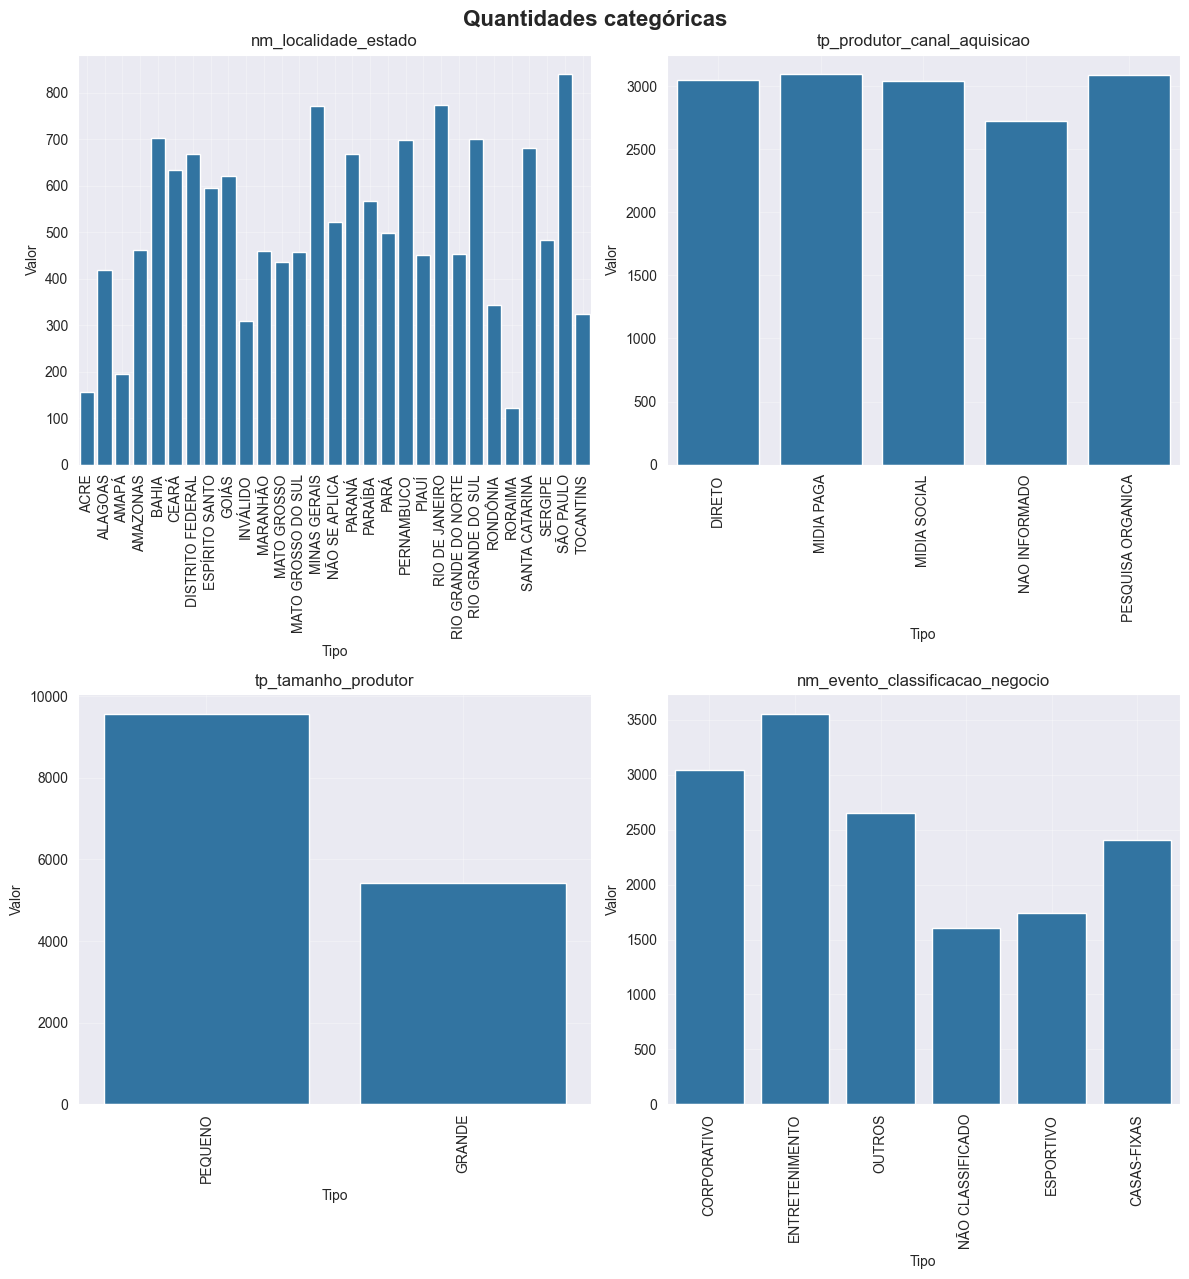

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(12, 13))
fig.suptitle('Quantidades categóricas', fontsize=16, fontweight='bold')
ax = ax.flatten()

temp = df[GROUPS]

for i, ax in enumerate(ax):
    sns.countplot(temp, x=GROUPS[i], ax=ax)
    ax.set_title(GROUPS[i])
    ax.set_xlabel('Tipo')
    ax.set_ylabel('Valor')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=90)

# Ajustar layout
plt.tight_layout()
plt.show()

In [10]:
# Months by groups
(
    df
    .groupby(GROUPS, as_index=False)
    .agg({'dt_venda': ['nunique', 'min', 'max']})
    .sort_values(by=[('dt_venda', 'nunique'), ('dt_venda', 'min')], ascending=False))

nm_localidade_estado tp_produtor_canal_aquisicao tp_tamanho_produtor  \
                                                                            
33                ALAGOAS                      DIRETO              GRANDE   
37                ALAGOAS                      DIRETO             PEQUENO   
38                ALAGOAS                      DIRETO             PEQUENO   
41                ALAGOAS                      DIRETO             PEQUENO   
44                ALAGOAS                  MIDIA PAGA              GRANDE   
...                   ...                         ...                 ...   
1305              SERGIPE                      DIRETO              GRANDE   
1315              SERGIPE                  MIDIA PAGA              GRANDE   
1325              SERGIPE                MIDIA SOCIAL              GRANDE   
1335              SERGIPE               NAO INFORMADO              GRANDE   
1345              SERGIPE           PESQUISA ORGANICA              GRANDE   

     nm_evento_classificacao_negocio dt_venda                        
                                      nunique        min        max  
33                    ENTRETENIMENTO       14 2033-02-01 2034-03-01  
37                       CORPORATIVO       14 2033-02-01 2034-03-01  
38                    ENTRETENIMENTO       14 2033-02-01 2034-03-01  
41                            OUTROS       14 2033-02-01 2034-03-01  
44                    ENTRETENIMENTO       14 2033-02-01 2034-03-01  
...                              ...      ...        ...        ...  
1305                          OUTROS        1 2033-02-01 2033-02-01  
1315                          OUTROS        1 2033-02-01 2033-02-01  
1325                          OUTROS        1 2033-02-01 2033-02-01  
1335                          OUTROS        1 2033-02-01 2033-02-01  
1345                          OUTROS        1 2033-02-01 2033-02-01  

[1462 rows x 7 columns]

In [11]:
# Remove groups with less then 9 months
df_groups_qtd = (
    df
    .groupby(GROUPS, as_index=False)
    .agg({'dt_venda': 'nunique'}))

df_groups_qtd.columns = ['nm_localidade_estado', 'tp_produtor_canal_aquisicao', 'tp_tamanho_produtor', 'nm_evento_classificacao_negocio', 'meses_totais']
df_filter = df.merge(df_groups_qtd, on=['nm_localidade_estado', 'tp_produtor_canal_aquisicao', 'tp_tamanho_produtor', 'nm_evento_classificacao_negocio'], how='left').reset_index(drop=True)
df_filter = df_filter[df_filter.meses_totais >= 9]
df_filter.sort_values(by='dt_venda').reset_index(drop=True, inplace=True)

In [12]:
# Check month gaps

def verificar_gaps_mensais(serie_temporal, coluna_data='dt_venda'):
    
    df = serie_temporal.copy()
    df[coluna_data] = pd.to_datetime(df[coluna_data])
    df = df.sort_values(coluna_data)
    df['ano_mes'] = df[coluna_data].dt.to_period('M')
    
    meses_presentes = df['ano_mes'].unique()
    print(meses_presentes)
    meses_range = pd.period_range(
        start=meses_presentes.min(),
        end=meses_presentes.max(),
        freq='M'
    )
    
    meses_faltantes = set(meses_range) - set(meses_presentes)
    meses_faltantes = sorted(list(meses_faltantes))
    
    gaps_sequencia = []
    if meses_faltantes:
        sequencia_atual = [meses_faltantes[0]]
        
        for i in range(1, len(meses_faltantes)):
            diff_meses = meses_faltantes[i].month - meses_faltantes[i-1].month
            diff_anos = meses_faltantes[i].year - meses_faltantes[i-1].year
            
            if (diff_anos == 0 and diff_meses == 1) or (diff_anos == 1 and meses_faltantes[i-1].month == 12 and meses_faltantes[i].month == 1):
                sequencia_atual.append(meses_faltantes[i])
            else:
                gaps_sequencia.append(sequencia_atual)
                sequencia_atual = [meses_faltantes[i]]
        
        gaps_sequencia.append(sequencia_atual)
    
    return meses_faltantes, gaps_sequencia

gaps_groups = []
groups = df_filter.groupby(GROUPS)
for gp in list(groups.groups.keys()):
    m, g = verificar_gaps_mensais(
        df_filter[
            (df_filter.nm_localidade_estado == gp[0]) & 
            (df_filter.tp_produtor_canal_aquisicao == gp[1]) & 
            (df_filter.tp_tamanho_produtor == gp[2]) & 
            (df_filter.nm_evento_classificacao_negocio == gp[3])])
    temp = {
        'grupo': gp,
        'meses': len(m)
        }
    gaps_groups.append(temp)

<PeriodArray>
['2033-02', '2033-03', '2033-04', '2033-06', '2033-07', '2033-08', '2033-09',
 '2033-10', '2033-11', '2033-12', '2034-02']
Length: 11, dtype: period[M]
<PeriodArray>
['2033-02', '2033-03', '2033-04', '2033-05', '2033-06', '2033-07', '2033-08',
 '2033-09', '2033-10', '2033-11', '2033-12', '2034-02', '2034-03']
Length: 13, dtype: period[M]
<PeriodArray>
['2033-02', '2033-03', '2033-04', '2033-05', '2033-06', '2033-07', '2033-08',
 '2033-09', '2033-10', '2033-11', '2033-12', '2034-02', '2034-03']
Length: 13, dtype: period[M]
<PeriodArray>
['2033-02', '2033-03', '2033-06', '2033-07', '2033-09', '2033-10', '2033-11',
 '2033-12', '2034-02']
Length: 9, dtype: period[M]
<PeriodArray>
['2033-02', '2033-03', '2033-04', '2033-06', '2033-07', '2033-08', '2033-09',
 '2033-10', '2033-11', '2033-12', '2034-02', '2034-03']
Length: 12, dtype: period[M]
<PeriodArray>
['2033-02', '2033-03', '2033-04', '2033-05', '2033-06', '2033-07', '2033-08',
 '2033-09', '2033-10', '2033-11', '2033-12', '

In [13]:
pd.DataFrame(gaps_groups).sort_values(by='meses', ascending=False)

,grupo,meses
654,"(PIAUÍ, MIDIA PAGA, GRANDE, CASAS-FIXAS)",5
649,"(PIAUÍ, DIRETO, GRANDE, CASAS-FIXAS)",5
839,"(SANTA CATARINA, DIRETO, GRANDE, OUTROS)",5
849,"(SANTA CATARINA, MIDIA PAGA, GRANDE, OUTROS)",5
859,"(SANTA CATARINA, MIDIA SOCIAL, GRANDE, OUTROS)",5
...,...,...
457,"(NÃO SE APLICA, MIDIA SOCIAL, PEQUENO, NÃO CLA...",0
458,"(NÃO SE APLICA, MIDIA SOCIAL, PEQUENO, OUTROS)",0
459,"(NÃO SE APLICA, NAO INFORMADO, GRANDE, CORPORA...",0
122,"(CEARÁ, DIRETO, PEQUENO, ESPORTIVO)",0


In [14]:
df_filter.shape

(13068, 13)

In [92]:
df_filter_int = df_filter.copy()
df_filter_int = df_filter_int.set_index('dt_venda').sort_index()
df_filled = df_filter_int.groupby(GROUPS, as_index=False).resample('MS').ffill()
df_filled = df_filled.reset_index(level=0, drop=True)

In [93]:
df_filled = df_filled.sort_values(by='dt_venda').reset_index()
df_filled.drop(columns=['meses_totais'], inplace=True)

In [94]:
df_filled.describe()

,dt_venda,vr_venda,qt_ingresso,qt_evento,qt_produtor,qt_ingresso_por_evento,qt_evento_por_produtor,vr_medio_ingresso
count,13505,1.350500e+04,13505.000000,13505.000000,13505.000000,13505.000000,13505.000000,13505.000000
mean,2033-08-16 03:53:05.220288512,6.226260e+04,1522.111902,77.318596,39.307893,26.425805,2.531782,56.918632
min,2033-02-01 00:00:00,-1.432700e+03,1.000000,1.000000,1.000000,1.000000,1.000000,-354.170000
25%,2033-05-01 00:00:00,1.121390e+03,30.000000,3.000000,2.000000,4.390000,1.000000,23.080000
50%,2033-08-01 00:00:00,5.946870e+03,142.000000,11.000000,6.000000,10.250000,1.300000,36.150000
75%,2033-12-01 00:00:00,2.746486e+04,692.000000,47.000000,24.000000,24.900000,2.000000,59.190000
max,2034-03-01 00:00:00,4.177209e+06,133641.000000,3473.000000,1609.000000,2313.000000,226.000000,3451.920000
std,NaN,2.139738e+05,5474.407334,237.717925,119.921224,67.065043,5.747268,93.489922


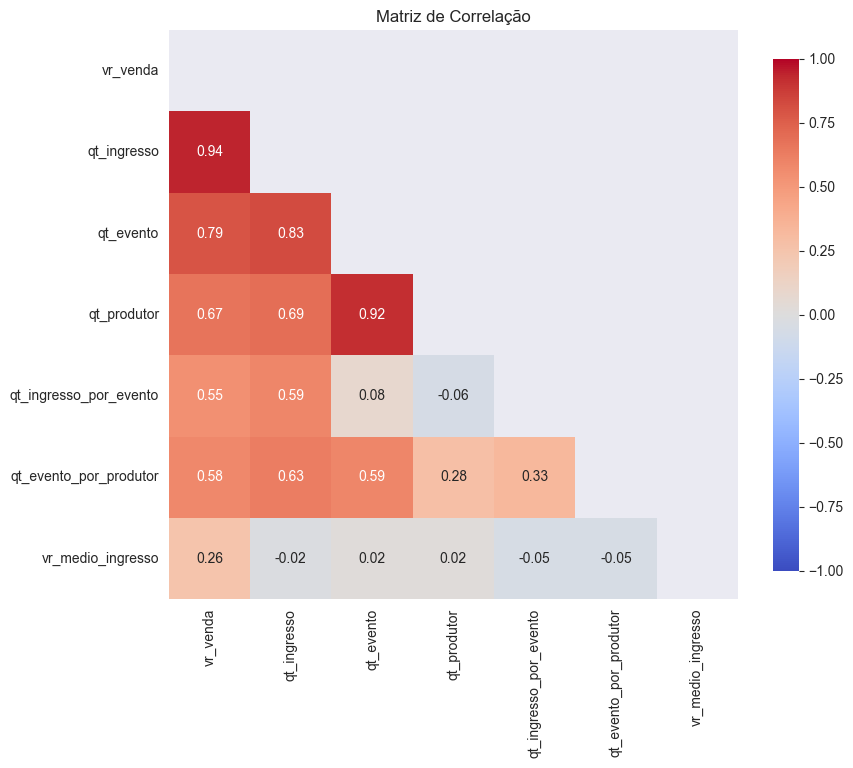

In [95]:
# Correlation
corr = df_filled.select_dtypes(include='number').corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(9, 8))
sns.heatmap(corr, 
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            cbar_kws={'shrink': 0.8},
            vmin=-1, 
            vmax=1)

plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

In [96]:
# Quantidade de ingressos, com certeza se relaciona com o valor total de vendas
# Quantidade produtor e quantidade evento tem uma correlação altíssima, portanto, qt_produtor será removido
df_filled.drop(columns=['qt_produtor', 'qt_evento'], inplace=True)

In [108]:
temp_df

,dt_venda,vr_venda,qt_ingresso,qt_ingresso_por_evento,qt_evento_por_produtor,vr_medio_ingresso,dt_sem_hora
0,2033-02-01,906.49,40.0,10.00,1.00,24.34,2033-02-01
1,2033-02-01,2416.27,30.0,1.67,1.06,71.41,2033-02-01
2,2033-02-01,6425.07,295.0,3.24,1.32,20.81,2033-02-01
3,2033-02-01,214.07,12.0,2.40,1.00,14.22,2033-02-01
4,2033-02-01,81.96,2.0,2.00,1.00,38.29,2033-02-01
...,...,...,...,...,...,...,...
13500,2034-03-01,129.12,8.0,8.00,1.00,14.74,2034-03-01
13501,2034-03-01,950.24,28.0,5.60,1.25,30.32,2034-03-01
13502,2034-03-01,532.43,28.0,2.80,1.43,19.71,2034-03-01
13503,2034-03-01,6744.11,187.0,6.03,1.19,33.96,2034-03-01


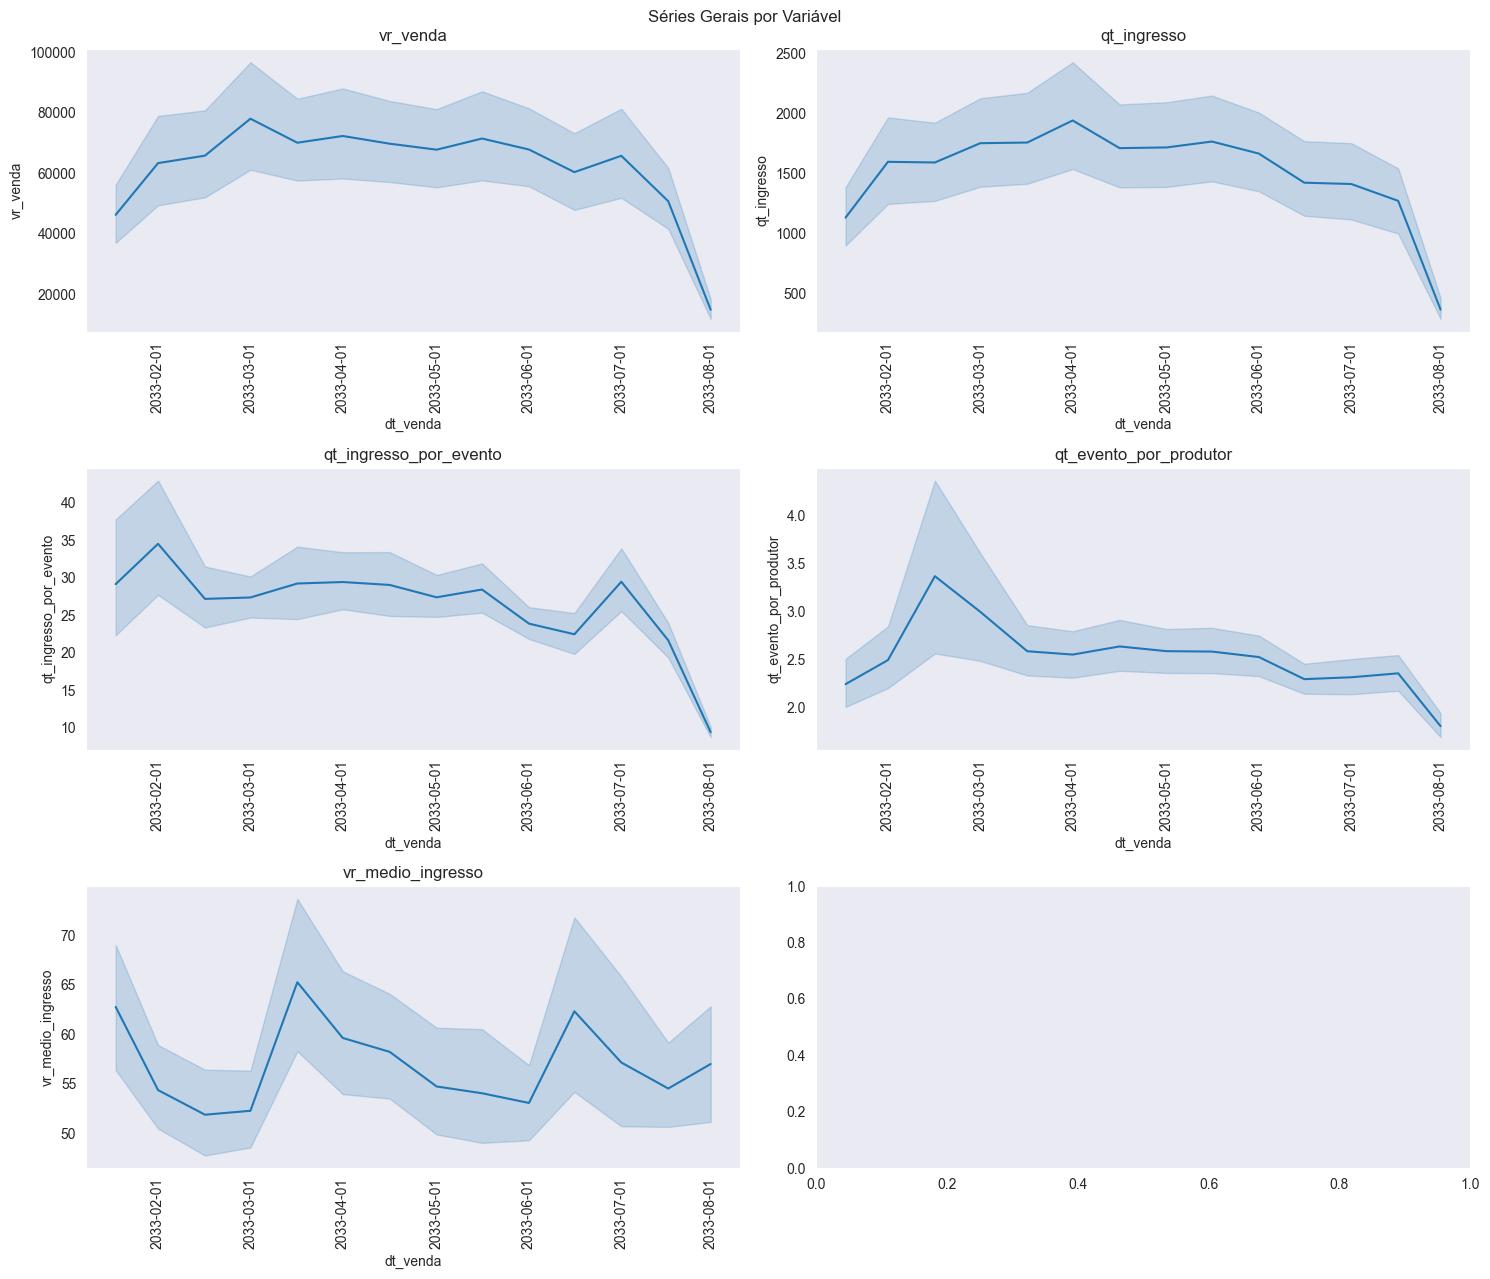

In [111]:
fig, ax = plt.subplots(3, 2, figsize=(15, 13))
ax = ax.flatten()

temp_df = df_filled.select_dtypes(exclude='object')
temp_df['dt_sem_hora'] = temp_df['dt_venda'].dt.date

for i, j in zip(range(len(temp_df.columns[1:-1])), temp_df.columns[1:-1]):
    sns.lineplot(temp_df, x='dt_venda', y=j, ax=ax[i])
    ax[i].set_title(j)
    ax[i].set_xticklabels(temp_df.dt_sem_hora.unique(), rotation=90)

# Ajustar layout
fig.suptitle('Séries Gerais por Variável')
plt.tight_layout()
plt.show()

In [125]:
# Sazonality not observed because the functions work only with 18 minimal observations

## Modeling

In [42]:
from statsforecast import StatsForecast
from mlforecast import MLForecast
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error


### Preparing data

In [72]:
df_modeling = df_filled.copy()
df_modeling['unique_id'] = df_modeling.apply(lambda x: f"{x[GROUPS[0]]}_{x[GROUPS[1]]}_{x[GROUPS[2]]}_{x[GROUPS[3]]}", axis=1)

In [73]:
# Split in train, test leave 3 last months to test
train_dfs = []
test_dfs = []
groups = df_modeling.groupby(GROUPS)
    
for gp in list(groups.groups.keys()):
    group_df = (
        df_modeling[
            (df_modeling.nm_localidade_estado == gp[0]) & 
            (df_modeling.tp_produtor_canal_aquisicao == gp[1]) & 
            (df_modeling.tp_tamanho_produtor == gp[2]) & 
            (df_modeling.nm_evento_classificacao_negocio == gp[3])]
        ).sort_values('dt_venda')
    
    # Encontrar a data de corte para cada grupo
    max_date = group_df['dt_venda'].max()
    cutoff_date = max_date - pd.DateOffset(months=3)
    
    # Dividir os dados
    train_data = group_df[group_df['dt_venda'] <= cutoff_date]
    test_data = group_df[group_df['dt_venda'] > cutoff_date]
    
    train_dfs.append(train_data)
    test_dfs.append(test_data)

train = pd.concat(train_dfs, ignore_index=True).reset_index(drop=True)
test = pd.concat(test_dfs, ignore_index=True).reset_index(drop=True)

In [113]:
# Rename columns to model
train.rename(columns={'dt_venda': 'ds', 'vr_venda': 'y'}, inplace=True)
test.rename(columns={'dt_venda': 'ds', 'vr_venda': 'y'}, inplace=True)

# # Keep necessary columns
model_cols = ['ds', 'unique_id', 'y', 'qt_ingresso', 'qt_evento', 
              'qt_ingresso_por_evento', 'qt_evento_por_produtor', 
              'vr_medio_ingresso']

train_df = train[model_cols]
test_df = test[model_cols]

### Baseline

In [118]:
from statsforecast.models import Naive, SeasonalNaive, AutoARIMA

models = [
    Naive(), 
    SeasonalNaive(season_length=1), 
    SeasonalNaive(season_length=2, alias='SeasonalNaive2'),
    SeasonalNaive(season_length=3, alias='SeasonalNaive3')
    ]

sf = StatsForecast(
    models=models,
    freq='MS',
    n_jobs=-1)

baseline_res = sf.forecast(df=train_df, h=3, X_df=test_df.drop(columns=['y']), level=[90])

In [119]:
baseline_res = (
    baseline_res
    .reset_index(drop=True)
    .merge(test_df[['ds', 'unique_id', 'y']], on=['ds', 'unique_id'], how='left'))

mape_naive, mae_naive = mean_absolute_percentage_error(baseline_res['y'].values, baseline_res['Naive'].values), mean_absolute_error(baseline_res['y'].values, baseline_res['Naive'].values)
mape_sea1, mae_sea1 = mean_absolute_percentage_error(baseline_res['y'].values, baseline_res['SeasonalNaive'].values), mean_absolute_error(baseline_res['y'].values, baseline_res['SeasonalNaive'].values)
mape_sea2, mae_sea2 = mean_absolute_percentage_error(baseline_res['y'].values, baseline_res['SeasonalNaive2'].values), mean_absolute_error(baseline_res['y'].values, baseline_res['SeasonalNaive2'].values)
mape_sea3, mae_sea3 = mean_absolute_percentage_error(baseline_res['y'].values, baseline_res['SeasonalNaive3'].values), mean_absolute_error(baseline_res['y'].values, baseline_res['SeasonalNaive3'].values)

print(f'Naive -- MAPE: {mape_naive} - MAE: {mae_naive}')
print(f'SeasonalNaive -- MAPE: {mape_sea1} - MAE: {mae_sea1}')
print(f'SeasonalNaive2 -- MAPE: {mape_sea2} - MAE: {mae_sea2}')
print(f'SeasonalNaive3 -- MAPE: {mape_sea3} - MAE: {mae_sea3}')

Naive -- MAPE: 9.940177919362709 - MAE: 29058.741488575266
SeasonalNaive -- MAPE: 9.940177919362709 - MAE: 29058.741488575266
SeasonalNaive2 -- MAPE: 14.807819237914007 - MAE: 34214.30923723118
SeasonalNaive3 -- MAPE: 16.773247304871447 - MAE: 34329.45538978495


### Outros modelos